# Clean Y

Registered PV commissioning counts in 2022 and 2023, with location-risk and availability flags.

In [1]:
from pathlib import Path
import zipfile
import numpy as np
import pandas as pd
import geopandas as gpd
from IPython.display import display

In [2]:
PROJECT_DIR = Path.cwd()
RAW_DIR = PROJECT_DIR / "Data" / "raw"
SUPPORT_DIR = PROJECT_DIR / "supporting_inputs"
OUTPUT_DIR = PROJECT_DIR / "cleaning_outputs_simple"
OUTPUT_DIR.mkdir(exist_ok=True)

## Municipality identifiers

In [3]:
municipality_changes = pd.read_csv(SUPPORT_DIR / "bfs_commune_mutations.csv")
municipalities = pd.read_csv(SUPPORT_DIR / "bfs_levels_2026.csv")
municipalities = municipalities[["BfsCode", "Name", "CantonId", "Canton"]]
municipalities = municipalities.rename(columns={
    "BfsCode": "bfs", "Name": "commune", "CantonId": "canton_id", "Canton": "canton"})
assert municipalities["bfs"].is_unique
valid_ids = set(municipalities["bfs"])
print("2026 municipalities:", len(municipalities))

2026 municipalities: 2110


In [4]:
display(municipalities.head())

,bfs,commune,canton_id,canton
0,6158,Vionnaz,23,Valais / Wallis
1,3023,Speicher,15,Appenzell Ausserrhoden
2,6011,Zwischbergen,23,Valais / Wallis
3,2228,Villars-sur-Glâne,10,Fribourg / Freiburg
4,2230,Villarsel-sur-Marly,10,Fribourg / Freiburg


In [5]:
changed_identifier = municipality_changes["InitialCode"] != municipality_changes["TerminalCode"]
merger_links = municipality_changes.loc[changed_identifier]
merger_links = merger_links[["InitialCode", "TerminalCode"]]
merger_links = merger_links.drop_duplicates()
assert merger_links["InitialCode"].is_unique, "Ambiguous municipality merger links."
next_identifier = dict(zip(merger_links["InitialCode"], merger_links["TerminalCode"]))

In [29]:
display(merger_links.head())
print(next_identifier[343])

,InitialCode,TerminalCode
0,343,329
2,531,540
4,601,619
6,752,756
7,753,756


329


In [6]:
def to_2026(source_identifier):
    if pd.isna(source_identifier):
        return np.nan
    current_identifier = int(source_identifier)
    visited_identifiers = set()
    while current_identifier in next_identifier:
        assert current_identifier not in visited_identifiers, "Cycle in municipality merger links."
        visited_identifiers.add(current_identifier)
        destination_identifier = next_identifier[current_identifier]
        current_identifier = int(destination_identifier)
    return current_identifier

In [30]:
print(to_2026(343))
print(to_2026(np.nan))

329
nan


## Read plant records

In [7]:
print("Reading plant records...", flush=True)
with zipfile.ZipFile(RAW_DIR / "bfe_plants.csv.zip") as archive:
    plants = pd.read_csv(archive.open("ElectricityProductionPlant.csv"))
    subcategories = pd.read_csv(archive.open("SubCategoryCatalogue.csv"))
assert plants["xtf_id"].is_unique, "Duplicate plant identifiers require review."
print("Registered plants:", len(plants))
display(subcategories[["Catalogue_id", "en"]])

Reading plant records...
Registered plants: 339499


,Catalogue_id,en
0,subcat_1,Hydroelectric power
1,subcat_2,Photovoltaic
2,subcat_3,Wind energy
3,subcat_4,Biomass
4,subcat_5,Geothermal energy
5,subcat_6,Nuclear energy
6,subcat_7,Crude oil
7,subcat_8,Natural gas
8,subcat_9,Coal
9,subcat_10,Waste


In [31]:
preview_columns = ["xtf_id", "SubCategory", "BeginningOfOperation", "_x", "_y"]
display(plants[preview_columns].head())

,xtf_id,SubCategory,BeginningOfOperation,_x,_y
0,5686,subcat_1,1969-09-01,2642480.025,1130235.125
1,5726,subcat_1,2024-01-16,NaN,NaN
2,5727,subcat_1,1907-03-01,2808646.000,1123676.000
3,5730,subcat_1,1922-01-01,2778481.000,1198505.000
4,5740,subcat_1,1962-03-18,NaN,NaN


## Select PV and commissioning years

In [8]:
is_photovoltaic = plants["SubCategory"] == "subcat_2"
solar = plants.loc[is_photovoltaic]
solar = solar.copy()
solar["date"] = pd.to_datetime(solar["BeginningOfOperation"], errors="coerce")
solar["year"] = solar["date"].dt.year
print("PV records:", len(solar))
print("Missing or invalid commissioning dates:", solar["date"].isna().sum())
is_selected_year = solar["year"].isin([2022, 2023])
solar = solar.loc[is_selected_year].copy()
solar["year"] = solar["year"].astype(int)
annual_record_counts = solar.groupby("year").size()
display(annual_record_counts.to_frame("PV_records"))

PV records: 337455
Missing or invalid commissioning dates: 0


,PV_records
year,
2022,33763
2023,61765


In [32]:
preview_columns = ["xtf_id", "SubCategory", "BeginningOfOperation", "year"]
display(solar[preview_columns].head())

,xtf_id,SubCategory,BeginningOfOperation,year
15700,54142,subcat_2,2022-10-26,2022
22067,65127,subcat_2,2022-01-27,2022
28533,76308,subcat_2,2022-04-25,2022
39627,92529,subcat_2,2023-03-09,2023
47462,102177,subcat_2,2022-06-13,2022


## Prepare municipality boundaries

In [9]:
print("Reading boundary polygons...", flush=True)
boundaries_raw = gpd.read_file(RAW_DIR / "swiss_boundaries_2020.geojson")
is_municipality = boundaries_raw["OBJEKTART"] == "Gemeindegebiet"
is_switzerland = boundaries_raw["ICC"] == "CH"
boundaries = boundaries_raw.loc[is_municipality & is_switzerland]
boundaries = boundaries[["BFS_NUMMER", "geometry"]].copy()
boundaries["bfs"] = boundaries["BFS_NUMMER"].map(to_2026)
is_known_municipality = boundaries["bfs"].isin(valid_ids)
boundaries = boundaries.loc[is_known_municipality]
boundaries = boundaries[["bfs", "geometry"]]

Reading boundary polygons...


In [10]:
boundaries = boundaries.dissolve(by="bfs")
boundaries = boundaries.reset_index()
assert boundaries.crs.to_epsg() == 4326
assert boundaries.is_valid.all()
print("Municipality polygons:", len(boundaries))

Municipality polygons: 2110


In [33]:
display(boundaries.head())

,bfs,geometry
0,1,"POLYGON ((8.47242 47.26338, 8.47272 47.26348, ..."
1,2,"POLYGON ((8.44447 47.26622, 8.4428 47.26752, 8..."
2,3,"POLYGON ((8.44132 47.31583, 8.44132 47.31588, ..."
3,4,"POLYGON ((8.53545 47.26097, 8.53551 47.26094, ..."
4,5,"POLYGON ((8.44132 47.31583, 8.44138 47.31576, ..."


<Axes: xlabel='Geodetic longitude [degree]', ylabel='Geodetic latitude [degree]'>

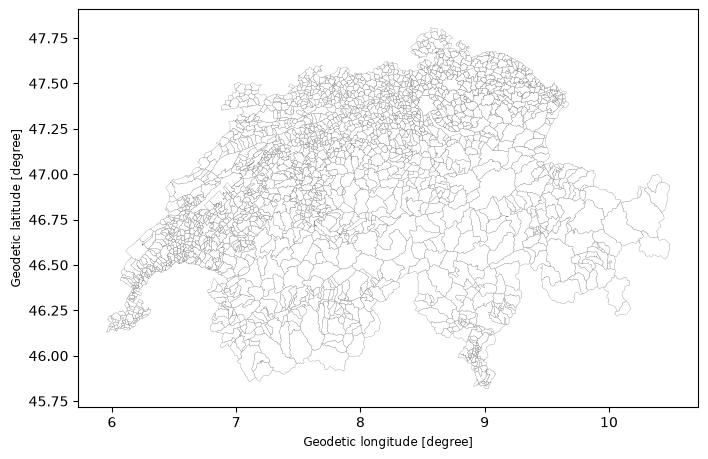

In [34]:
boundaries.plot(figsize=(8, 6), facecolor="white", edgecolor="grey", linewidth=0.2)

## Match plant coordinates

In [11]:
has_x_coordinate = solar["_x"].notna()
has_y_coordinate = solar["_y"].notna()
coordinate_records = solar.loc[has_x_coordinate & has_y_coordinate]
plant_identifiers = coordinate_records[["xtf_id"]]
point_geometry = gpd.points_from_xy(coordinate_records["_x"], coordinate_records["_y"])
plant_points = gpd.GeoDataFrame(plant_identifiers, geometry=point_geometry, crs="EPSG:2056")
plant_points = plant_points.to_crs(boundaries.crs)
print("Matching coordinate points:", len(plant_points), flush=True)
spatial_matches = gpd.sjoin(plant_points, boundaries, how="left", predicate="intersects")

Matching coordinate points: 94799


In [35]:
display(plant_points.head())

,xtf_id,geometry
15700,54142,POINT (8.97133 47.16612)
22067,65127,POINT (7.52482 46.96117)
28533,76308,POINT (7.61022 47.48862)
39627,92529,POINT (7.4263 46.17112)
47462,102177,POINT (8.49464 47.23912)


In [36]:
display(spatial_matches[["xtf_id", "bfs"]].head())

,xtf_id,bfs
15700,54142,1345
22067,65127,358
28533,76308,2473
39627,92529,6084
47462,102177,12


In [12]:
plant_match_groups = spatial_matches.groupby("xtf_id")
municipality_match_counts = plant_match_groups["bfs"].nunique()
has_one_municipality = municipality_match_counts == 1
unambiguous_plant_ids = municipality_match_counts.loc[has_one_municipality].index
is_unambiguous = spatial_matches["xtf_id"].isin(unambiguous_plant_ids)
unique_matches = spatial_matches.loc[is_unambiguous]
unique_matches = unique_matches.drop_duplicates("xtf_id")
coordinate_lookup = unique_matches.set_index("xtf_id")
solar["bfs"] = solar["xtf_id"].map(coordinate_lookup["bfs"])
solar["assignment"] = "unresolved"
has_municipality = solar["bfs"].notna()
solar.loc[has_municipality, "assignment"] = "coordinates"

In [37]:
display(solar[["xtf_id", "bfs", "assignment"]].head())

,xtf_id,bfs,assignment
15700,54142,1345,coordinates
22067,65127,358,coordinates
28533,76308,2473,coordinates
39627,92529,6084,coordinates
47462,102177,12,coordinates


In [38]:
display(solar["assignment"].value_counts())

assignment
coordinates          94799
postcode_locality      472
unresolved             257
Name: count, dtype: int64

## Prepare postal matching fields

In [13]:
with zipfile.ZipFile(SUPPORT_DIR / "ortschaftenverzeichnis_plz.csv.zip") as archive:
    csv_members = []
    for member_name in archive.namelist():
        if member_name.endswith(".csv"):
            csv_members.append(member_name)
    postcodes = pd.read_csv(archive.open(csv_members[0]), sep=";")
postcodes["bfs"] = postcodes["BFS-Nr"].map(to_2026)
is_known_municipality = postcodes["bfs"].isin(valid_ids)
postcodes = postcodes.loc[is_known_municipality].copy()

In [39]:
preview_columns = ["PLZ4", "Ortschaftsname", "Kantonskürzel", "BFS-Nr", "bfs"]
display(postcodes[preview_columns].head())

,PLZ4,Ortschaftsname,Kantonskürzel,BFS-Nr,bfs
0,1000,Lausanne 25,VD,5586,5586
1,1000,Lausanne 26,VD,5586,5586
2,1000,Lausanne 27,VD,5586,5586
3,1003,Lausanne,VD,5586,5586
4,1004,Lausanne,VD,5586,5586


In [14]:
postcodes["postcode"] = postcodes["PLZ4"].astype(str)
postcodes["postcode"] = postcodes["postcode"].str.zfill(4)
postcodes["locality"] = postcodes["Ortschaftsname"].astype(str)
postcodes["locality"] = postcodes["locality"].str.strip()
postcodes["locality"] = postcodes["locality"].str.casefold()
postcodes["canton_code"] = postcodes["Kantonskürzel"]

In [15]:
solar["postcode"] = solar["PostCode"].astype(str)
solar["postcode"] = solar["postcode"].str.replace(r"\.0$", "", regex=True)
solar["postcode"] = solar["postcode"].str.zfill(4)
solar["locality"] = solar["Municipality"].astype(str)
solar["locality"] = solar["locality"].str.strip()
solar["locality"] = solar["locality"].str.casefold()
solar["canton_code"] = solar["Canton"]

In [40]:
display(postcodes[["postcode", "locality", "canton_code", "bfs"]].head())

,postcode,locality,canton_code,bfs
0,1000,lausanne 25,VD,5586
1,1000,lausanne 26,VD,5586
2,1000,lausanne 27,VD,5586
3,1003,lausanne,VD,5586
4,1004,lausanne,VD,5586


In [41]:
display(solar[["PostCode", "postcode", "Municipality", "locality", "canton_code"]].head())

,PostCode,postcode,Municipality,locality,canton_code
15700,8864,8864,Reichenburg,reichenburg,SZ
22067,3066,3066,Stettlen,stettlen,BE
28533,4143,4143,Dornach,dornach,SO
39627,1982,1982,Euseigne,euseigne,VS
47462,8911,8911,Rifferswil,rifferswil,ZH


## Match postcode, locality and canton

In [16]:
locality_keys = ['postcode', 'locality', 'canton_code']
locality_groups = postcodes.groupby(locality_keys)
locality_lookup = locality_groups["bfs"].agg(["nunique", "first"])
locality_lookup = locality_lookup.reset_index()
locality_is_unique = locality_lookup["nunique"] == 1
locality_lookup = locality_lookup.loc[locality_is_unique]
locality_lookup = locality_lookup[locality_keys + ["first"]]

In [42]:
display(locality_lookup.head(10))

,postcode,locality,canton_code,first
0,1000,lausanne 25,VD,5586
1,1000,lausanne 26,VD,5586
2,1000,lausanne 27,VD,5586
3,1003,lausanne,VD,5586
4,1004,lausanne,VD,5586
5,1005,lausanne,VD,5586
6,1006,lausanne,VD,5586
7,1007,lausanne,VD,5586
8,1008,jouxtens-mézery,VD,5585
9,1008,prilly,VD,5589


In [17]:
needs_locality_match = solar["bfs"].isna()
locality_unresolved = solar.loc[needs_locality_match]
locality_unresolved = locality_unresolved[["xtf_id"] + locality_keys]
locality_matches = locality_unresolved.merge(
    locality_lookup, on=locality_keys, how="left", validate="m:1")
locality_mapping = locality_matches.set_index("xtf_id")
locality_suggested = solar["xtf_id"].map(locality_mapping["first"])
has_locality_suggestion = locality_suggested.notna()
locality_matched = needs_locality_match & has_locality_suggestion
solar.loc[locality_matched, "bfs"] = locality_suggested.loc[locality_matched]
solar.loc[locality_matched, "assignment"] = "postcode_locality"

In [43]:
matched_by_locality = solar["assignment"] == "postcode_locality"
preview_columns = ["xtf_id", "postcode", "locality", "canton_code", "bfs"]
display(solar.loc[matched_by_locality, preview_columns].head())

,xtf_id,postcode,locality,canton_code,bfs
128737,196362,8645,jona,SG,3340
133833,202856,1018,lausanne,VD,5586
135342,204793,8408,winterthur,ZH,230
136903,206789,6648,minusio,TI,5118
139351,209919,6939,arosio,TI,5237


In [44]:
display(solar["assignment"].value_counts())

assignment
coordinates          94799
postcode_locality      472
unresolved             257
Name: count, dtype: int64

## Match postcode and canton

In [18]:
postcode_keys = ['postcode', 'canton_code']
postcode_groups = postcodes.groupby(postcode_keys)
postcode_lookup = postcode_groups["bfs"].agg(["nunique", "first"])
postcode_lookup = postcode_lookup.reset_index()
postcode_is_unique = postcode_lookup["nunique"] == 1
postcode_lookup = postcode_lookup.loc[postcode_is_unique]
postcode_lookup = postcode_lookup[postcode_keys + ["first"]]

In [19]:
needs_postcode_match = solar["bfs"].isna()
postcode_unresolved = solar.loc[needs_postcode_match]
postcode_unresolved = postcode_unresolved[["xtf_id"] + postcode_keys]
postcode_matches = postcode_unresolved.merge(
    postcode_lookup, on=postcode_keys, how="left", validate="m:1")
postcode_mapping = postcode_matches.set_index("xtf_id")
postcode_suggested = solar["xtf_id"].map(postcode_mapping["first"])
has_postcode_suggestion = postcode_suggested.notna()
postcode_matched = needs_postcode_match & has_postcode_suggestion
solar.loc[postcode_matched, "bfs"] = postcode_suggested.loc[postcode_matched]
solar.loc[postcode_matched, "assignment"] = "postcode_unique"

In [45]:
print("New matches in this run:", postcode_matched.sum())
display(solar["assignment"].value_counts())

New matches in this run: 0


assignment
coordinates          94799
postcode_locality      472
unresolved             257
Name: count, dtype: int64

In [20]:
solar["bfs"] = solar["bfs"].astype("Int64")
assignment_counts = solar.groupby(["year", "assignment"]).size()
assignment_counts = assignment_counts.unstack(fill_value=0)
display(assignment_counts)
is_unresolved = solar["bfs"].isna()
unresolved_records = solar.loc[is_unresolved].copy()
print("Unresolved records:", len(unresolved_records))

assignment,coordinates,postcode_locality,unresolved
year,,,
2022,33542,136,85
2023,61257,336,172


Unresolved records: 257


In [46]:
preview_columns = ["xtf_id", "year", "postcode", "locality", "canton_code", "bfs"]
display(unresolved_records[preview_columns].head())

,xtf_id,year,postcode,locality,canton_code,bfs
122585,188201,2022,8217,wilchingen,SH,<NA>
130991,199192,2022,9055,bühler,AR,<NA>
136447,206206,2022,9435,heerbrugg,SG,<NA>
138148,208372,2022,1807,blonay,VD,<NA>
138672,209066,2022,3360,herzogenbuchsee,BE,<NA>


## Identify locations at risk

Use postal candidates, then the canton, then all municipalities if neither is known.

In [21]:
canton_labels = ["ZH", "BE", "LU", "UR", "SZ", "OW", "NW", "GL", "ZG", "FR",
                 "SO", "BS", "BL", "SH", "AR", "AI", "SG", "GR", "AG", "TG",
                 "TI", "VD", "VS", "NE", "GE", "JU"]
canton_codes = dict(enumerate(canton_labels, start=1))
municipalities["canton_code"] = municipalities["canton_id"].map(canton_codes)
postal_candidates = postcodes[["postcode", "canton_code", "bfs"]]
postal_candidates = postal_candidates.drop_duplicates()
uncertain_cells = set()

In [47]:
display(municipalities[["bfs", "commune", "canton_id", "canton_code"]].head())

,bfs,commune,canton_id,canton_code
0,6158,Vionnaz,23,VS
1,3023,Speicher,15,AR
2,6011,Zwischbergen,23,VS
3,2228,Villars-sur-Glâne,10,FR
4,2230,Villarsel-sur-Marly,10,FR


In [48]:
is_first_postcode = postal_candidates["postcode"] == "8217"
is_first_canton = postal_candidates["canton_code"] == "SH"
display(postal_candidates.loc[is_first_postcode & is_first_canton])

,postcode,canton_code,bfs
4614,8217,SH,2974
4615,8217,SH,2973
4616,8217,SH,2904


In [22]:
for record in unresolved_records.itertuples():
    same_postcode = postal_candidates["postcode"] == record.postcode
    same_canton = postal_candidates["canton_code"] == record.canton_code
    candidate_rows = postal_candidates.loc[same_postcode & same_canton]
    candidate_ids = candidate_rows["bfs"]
    if candidate_ids.empty:
        same_canton = municipalities["canton_code"] == record.canton_code
        candidate_ids = municipalities.loc[same_canton, "bfs"]
        if record.canton_code == "BE":
            moutier_id = pd.Series([6831])  # Include Moutier's pre-2026 canton.
            candidate_ids = pd.concat([candidate_ids, moutier_id])
    if candidate_ids.empty:
        candidate_ids = municipalities["bfs"]
    for candidate_id in candidate_ids:
        municipality_year = (int(candidate_id), int(record.year))
        uncertain_cells.add(municipality_year)
print("Potentially affected municipality-year cells:", len(uncertain_cells))

Potentially affected municipality-year cells: 451


In [49]:
print((2974, 2022) in uncertain_cells)
print((2973, 2022) in uncertain_cells)
print((2904, 2022) in uncertain_cells)

True
True
True


## Count assigned records

In [23]:
is_assigned = solar["bfs"].notna()
assigned_records = solar.loc[is_assigned].copy()
annual_groups = assigned_records.groupby(["bfs", "year"])
registered_counts = annual_groups.size()
registered_counts = registered_counts.rename("Y_registered")
registered_counts = registered_counts.reset_index()
municipality_ids = sorted(valid_ids)
municipality_years = pd.MultiIndex.from_product(
    [municipality_ids, [2022, 2023]], names=["bfs", "year"])
municipality_year_grid = municipality_years.to_frame(index=False)

In [50]:
display(registered_counts.head())
display(municipality_year_grid.head())
print("Municipality-year rows:", len(municipality_year_grid))

,bfs,year,Y_registered
0,1,2022,4
1,1,2023,11
2,2,2022,26
3,2,2023,43
4,3,2022,14


,bfs,year
0,1,2022
1,1,2023
2,2,2022
3,2,2023
4,3,2022


Municipality-year rows: 4220


In [24]:
clean_y = municipality_year_grid.merge(
    registered_counts, on=["bfs", "year"], how="left", validate="1:1")
clean_y["Y_registered"] = clean_y["Y_registered"].fillna(0)
clean_y["Y_registered"] = clean_y["Y_registered"].astype(int)
risk_table = pd.DataFrame(list(uncertain_cells), columns=["bfs", "year"])
risk_table["unresolved_location_risk"] = True
clean_y = clean_y.merge(risk_table, on=["bfs", "year"], how="left", validate="1:1")
clean_y["unresolved_location_risk"] = clean_y["unresolved_location_risk"].fillna(False)
clean_y["unresolved_location_risk"] = clean_y["unresolved_location_risk"].astype(bool)

In [51]:
display(clean_y.head())

,bfs,year,Y,Y_available,Y_registered,has_polygon,unresolved_location_risk,register_zero,usable_zero
0,1,2022,4.0,True,4,True,False,False,False
1,1,2023,11.0,True,11,True,False,False,False
2,2,2022,26.0,True,26,True,False,False,False
3,2,2023,43.0,True,43,True,False,False,False
4,3,2022,14.0,True,14,True,False,False,False


In [52]:
example_towns = clean_y["bfs"].isin([2974, 2973, 2904])
example_year = clean_y["year"] == 2022
display(clean_y.loc[example_towns & example_year])

,bfs,year,Y,Y_available,Y_registered,has_polygon,unresolved_location_risk,register_zero,usable_zero
1936,2904,2022,NaN,False,16,True,True,False,False
1980,2973,2022,NaN,False,5,True,True,False,False
1982,2974,2022,NaN,False,8,True,True,False,False


## Separate usable zeros from unknown counts

A zero assigned-record count is not usable if location risk exists or a polygon is missing.

In [25]:
clean_y["has_polygon"] = clean_y["bfs"].isin(boundaries["bfs"])
no_location_risk = ~clean_y["unresolved_location_risk"]
clean_y["Y_available"] = clean_y["has_polygon"] & no_location_risk
clean_y["Y"] = clean_y["Y_registered"].astype(float)
is_unavailable = ~clean_y["Y_available"]
clean_y.loc[is_unavailable, "Y"] = np.nan
clean_y["register_zero"] = clean_y["Y_registered"] == 0
clean_y["usable_zero"] = clean_y["Y"] == 0

In [53]:
zero_examples = clean_y["usable_zero"]
preview_columns = ["bfs", "year", "Y_registered", "Y", "Y_available"]
display(clean_y.loc[zero_examples, preview_columns].head())

,bfs,year,Y_registered,Y,Y_available
137,95,2023,0,0.0,True
350,325,2022,0,0.0,True
374,341,2022,0,0.0,True
426,389,2022,0,0.0,True
456,410,2022,0,0.0,True


## Check counts and availability

In [26]:
duplicate_keys = clean_y.duplicated(["bfs", "year"])
assert not duplicate_keys.any()
assert clean_y["Y_registered"].sum() == len(assigned_records)
unknown_values = clean_y.loc[is_unavailable, "Y"]
assert unknown_values.isna().all()
usable_values = clean_y.loc[clean_y["Y_available"], "Y"]
usable_counts = clean_y.loc[clean_y["Y_available"], "Y_registered"]
usable_counts = usable_counts.astype(float)
assert usable_values.equals(usable_counts)
year_counts = clean_y.groupby("bfs")["year"].nunique()
assert (year_counts == 2).all()

In [54]:
display(year_counts.head())
print("All checks passed.")

bfs
1    2
2    2
3    2
4    2
5    2
Name: year, dtype: int64

All checks passed.


In [27]:
output_columns = ["bfs", "year", "Y", "Y_available", "Y_registered", "has_polygon",
                  "unresolved_location_risk", "register_zero", "usable_zero"]
clean_y = clean_y[output_columns]
display(clean_y.head(10))
availability_groups = clean_y.groupby("year")
availability = availability_groups.agg(
    municipalities=("bfs", "size"), usable_Y=("Y_available", "sum"),
    usable_zeros=("usable_zero", "sum"), location_risk=("unresolved_location_risk", "sum"))
display(availability)

,bfs,year,Y,Y_available,Y_registered,has_polygon,unresolved_location_risk,register_zero,usable_zero
0,1,2022,4.0,True,4,True,False,False,False
1,1,2023,11.0,True,11,True,False,False,False
2,2,2022,26.0,True,26,True,False,False,False
3,2,2023,43.0,True,43,True,False,False,False
4,3,2022,14.0,True,14,True,False,False,False
5,3,2023,25.0,True,25,True,False,False,False
6,4,2022,14.0,True,14,True,False,False,False
7,4,2023,20.0,True,20,True,False,False,False
8,5,2022,15.0,True,15,True,False,False,False
9,5,2023,42.0,True,42,True,False,False,False


,municipalities,usable_Y,usable_zeros,location_risk
year,,,,
2022,2110,1928,87,182
2023,2110,1841,46,269


In [28]:
counts_by_year = clean_y.pivot(index="bfs", columns="year", values="Y")
available_2022 = counts_by_year[2022].notna()
available_2023 = counts_by_year[2023].notna()
available_both_years = available_2022 & available_2023
print("Municipalities with both Y years available:", available_both_years.sum())
clean_y.to_csv(OUTPUT_DIR / "clean_Y.csv", index=False)
print("Saved: cleaning_outputs_simple/clean_Y.csv")

Municipalities with both Y years available: 1726
Saved: cleaning_outputs_simple/clean_Y.csv
